# 06 — Logical Operators, Code Distance, and Degeneracy

## Read before you begin

- Arthur Pesah, *Stabilizer Formalism II* (https://arthurpesah.me/blog/2023-03-16-stabilizer-formalism-2/).
- Exact sections to read: **Logical qubits**, **Pauli logical operators**, **Logical cosets**.
- Concepts to extract: why $k = n - m$ for $m$ independent stabilizer generators; the centralizer of the stabilizer group and how nontrivial logical operators arise from it; logical $X$ and $Z$ operators and logical equivalence modulo the stabilizer group; code distance defined via logical operator weight.

## Learning objectives

Notebooks 03 and 05 used stabilizers, syndromes, and (in Shor's case) an ad hoc brute-force distance check. This notebook makes those ideas precise and general, building each code the same way notebook 05 did — as a real `stim.Circuit` run on a `stim.TableauSimulator` — instead of hand-built NumPy Kronecker-product matrices. Classifying operators, checking logical equivalence, and searching for code distance is done with `stim.PauliString` (`.commutes()`, `.weight`, `.iter_all(...)`) and `TableauSimulator.peek_observable_expectation(...)`, the same primitives notebook 05 introduced. The one exception is the dimension-halving argument in Section 2: it is a statement about the *rank of a subspace*, and an explicit projector matrix shows that most directly, so that section alone keeps the small NumPy matrices notebook 05 otherwise moved away from. By the end you should be able to:

1. explain why $m$ independent stabilizer generators on $n$ qubits leave $k = n - m$ logical qubits, and see the dimension halve with each added generator;
2. define the centralizer $C(S)$ of a stabilizer group $S$, and explain why nontrivial logical operators are exactly the elements of $C(S)$ that are *not* in $S$ itself;
3. build logical $\bar{X}$ and $\bar{Z}$ operators and verify they anticommute, exactly like physical $X$ and $Z$;
4. show that logical operators differing by a stabilizer element are logically equivalent (they act identically on the code space);
5. state the general definition of code distance (minimum weight of a nontrivial logical operator) and apply one reusable Stim-based routine to compute it for the repetition code, Shor's code, and the Steane code.

**Expected outputs:** a demonstration of dimension-halving on the repetition code, an explicit centralizer/coset enumeration for the repetition code, circuit diagrams for all three codes' encoders, and a single reusable `code_distance` routine whose output matches what notebooks 02, 03, and 05 already established (distance 3 for all three codes examined here) — computed the same way for each, instead of three different ad hoc arguments.

**Assumes:** notebooks 02, 03, and 05 (the repetition, Shor, and Steane codes, and Stim's `TableauSimulator`/`PauliString` tools, reused here as worked examples rather than rebuilt from scratch).

## 1. Setup: three codes, built as real circuits

As in notebook 05, each code is an actual `stim.Circuit` that prepares $|0_L\rangle$, run through a `stim.TableauSimulator`. The repetition code needs no gates at all ($|0_L\rangle = |000\rangle$ already); the Shor and Steane encoders are exactly notebook 05's circuits. Seeing the circuit is part of understanding it, so each one is rendered with `stim.Circuit.diagram(...)` rather than printed as text.

In [1]:
import stim
import numpy as np


def repetition_encoding_circuit():
    return stim.Circuit()  # |0_L> = |000>, no gates needed


def shor_encoding_circuit():
    c = stim.Circuit()
    c.append("CX", [0, 3])
    c.append("CX", [0, 6])
    c.append("H", [0, 3, 6])
    c.append("CX", [0, 1])
    c.append("CX", [0, 2])
    c.append("CX", [3, 4])
    c.append("CX", [3, 5])
    c.append("CX", [6, 7])
    c.append("CX", [6, 8])
    return c


def steane_encoding_circuit():
    c = stim.Circuit()
    c.append("H", [2, 4, 5, 6])
    c.append("CX", [2, 0, 4, 0, 6, 0])
    c.append("CX", [2, 1, 5, 1, 6, 1])
    c.append("CX", [4, 3, 5, 3, 6, 3])
    return c


def bits_of(j, width):
    return tuple((j >> shift) & 1 for shift in reversed(range(width)))


# Same Hamming H as notebooks 04 and 05.
H_columns = [bits_of(j, width=3) for j in range(1, 8)]
H = tuple(tuple(col[row] for col in H_columns) for row in range(3))

repetition_generators = [stim.PauliString(s) for s in ["ZZI", "IZZ"]]
shor_generators = [stim.PauliString(s) for s in
                   ["ZZIIIIIII", "IZZIIIIII", "IIIZZIIII", "IIIIZZIII",
                    "IIIIIIZZI", "IIIIIIIZZ", "XXXXXXIII", "IIIXXXXXX"]]
steane_generators = [stim.PauliString(s) for s in
                     (["".join("X" if b else "I" for b in row) for row in H]
                      + ["".join("Z" if b else "I" for b in row) for row in H])]


def pretty(pauli_string):
    """Drop stim's leading sign character and render identities as 'I' instead of '_'."""
    return str(pauli_string)[1:].replace("_", "I")


print("Repetition:", [pretty(g) for g in repetition_generators])
print("Shor:      ", [pretty(g) for g in shor_generators])
print("Steane:    ", [pretty(g) for g in steane_generators])

Repetition: ['ZZI', 'IZZ']
Shor:       ['ZZIIIIIII', 'IZZIIIIII', 'IIIZZIIII', 'IIIIZZIII', 'IIIIIIZZI', 'IIIIIIIZZ', 'XXXXXXIII', 'IIIXXXXXX']
Steane:     ['IIIXXXX', 'IXXIIXX', 'XIXIXIX', 'IIIZZZZ', 'IZZIIZZ', 'ZIZIZIZ']


### The three encoding circuits

Shor-code encoder:


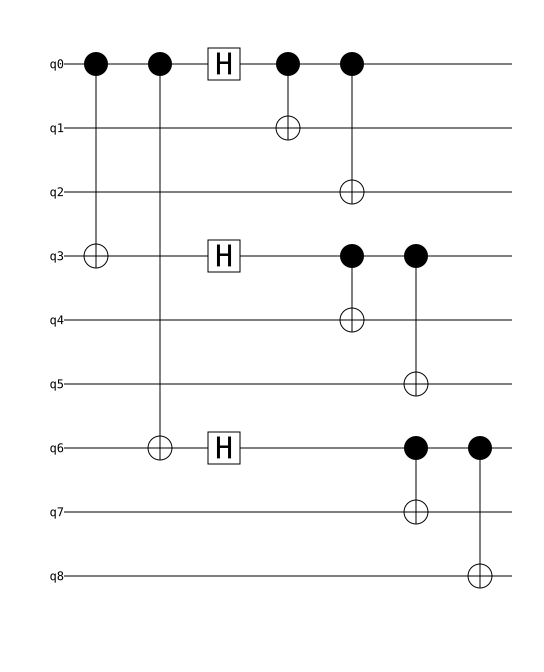

Steane-code encoder:


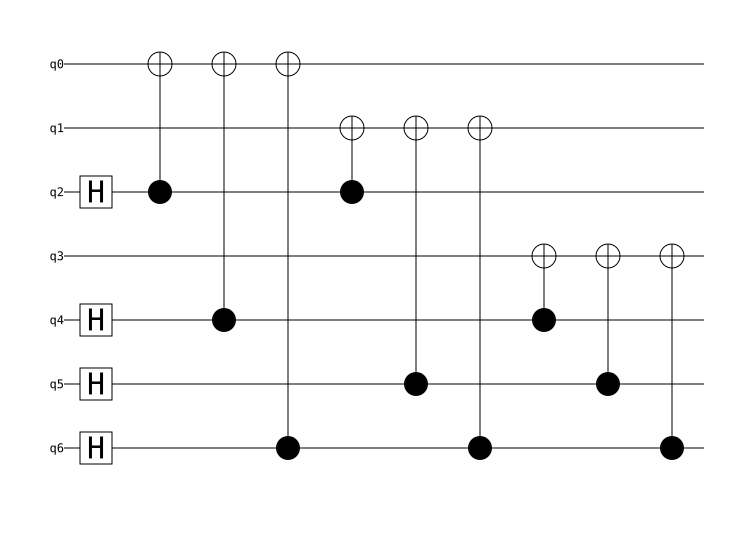

In [12]:
from IPython.display import display

# print("Repetition-code encoder (no gates: |0_L> is already |000>):")
# display(repetition_encoding_circuit().diagram("timeline-svg"))

print("Shor-code encoder:")
display(shor_encoding_circuit().diagram("timeline-svg"))

print("Steane-code encoder:")
display(steane_encoding_circuit().diagram("timeline-svg"))

In [17]:
def encoded_zero(circuit):
    sim = stim.TableauSimulator()
    sim.do(circuit)
    return sim

# Prepares logical 0 states
repetition_0L = encoded_zero(repetition_encoding_circuit())
shor_0L = encoded_zero(shor_encoding_circuit())
steane_0L = encoded_zero(steane_encoding_circuit())

for name, sim, gens in [("Repetition", repetition_0L, repetition_generators),
                            ("Shor", shor_0L, shor_generators),
                            ("Steane", steane_0L, steane_generators)]:
    eigenvalues = [sim.peek_observable_expectation(g) for g in gens]
    n = sim.num_qubits
    print(f"{name}: n={n} qubits, m={len(gens)} generators, "
          f"all eigenvalues +1: {all(e == 1 for e in eigenvalues)}")

Repetition: n=0 qubits, m=2 generators, all eigenvalues +1: True
Shor: n=9 qubits, m=8 generators, all eigenvalues +1: True
Steane: n=7 qubits, m=6 generators, all eigenvalues +1: True


## 2. Why $k = n - m$: dimension-halving

Each stabilizer generator $S_i$ is a Hermitian, unitary operator with eigenvalues $\pm 1$, so it splits the full $2^n$-dimensional space into two equal halves: a $+1$-eigenspace and a $-1$-eigenspace, each of dimension $2^{n-1}$. Demanding a *second, independent* generator also equal $+1$ cuts whatever space remains in half again — "independent" is doing real work here: it guarantees the new constraint isn't already implied by (or contradictory to) the first, so it genuinely halves the space rather than leaving it unchanged or emptying it. After $m$ independent constraints, the joint $+1$-eigenspace — the code space — has dimension $2^{n-m} = 2^k$.

This is a statement about the *rank of a subspace*, not about any particular circuit, and the clearest way to see it is still to build the projector operator explicitly and check its rank. So this section — only this section — drops back to the explicit NumPy Pauli matrices notebook 05 otherwise moved away from. We can watch this happen one generator at a time on the repetition code (3 qubits, so the full space is only 8-dimensional).

In [18]:
# This section works with the stabilizers as plain strings and explicit
# matrices -- the clearest way to see a *rank* argument -- rather than the
# stim.PauliString objects used everywhere else in this notebook.
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X, "Z": Z}


def kron_all(items):
    result = items[0]
    for m in items[1:]:
        result = np.kron(result, m)
    return result


def pauli_string_matrix(string):
    return kron_all([PAULI[ch] for ch in string])


def projector_onto_plus_one(generator_strings, n_qubits):
    dim = 2 ** n_qubits
    P = np.eye(dim, dtype=complex)
    for s in generator_strings:
        S = pauli_string_matrix(s)
        P = P @ ((np.eye(dim, dtype=complex) + S) / 2)
    return P


repetition_generator_strings = ["ZZI", "IZZ"]

print("Applying repetition-code generators one at a time:")
print(f"  no constraints:        dimension 2^3 = 8")
for i in range(1, len(repetition_generator_strings) + 1):
    P = projector_onto_plus_one(repetition_generator_strings[:i], n_qubits=3)
    rank = np.linalg.matrix_rank(P, tol=1e-8)
    print(f"  after {i} generator(s): dimension {rank}  (2^(3-{i}) = {2**(3-i)})")

Applying repetition-code generators one at a time:
  no constraints:        dimension 2^3 = 8
  after 1 generator(s): dimension 4  (2^(3-1) = 4)
  after 2 generator(s): dimension 2  (2^(3-2) = 2)


### Prediction 1

**Before running the next cell:** the Steane code has $n=7$ qubits and 6 independent generators (3 $X$-type, 3 $Z$-type, from notebook 05). What dimension do you expect its code space to have, and how many logical qubits $k$ does that correspond to?

In [14]:
for name, gens, n in [("Repetition", repetition_generators, 3),
                       ("Shor", shor_generators, 9),
                       ("Steane", steane_generators, 7)]:
    # Verify independence via Stim's own tableau construction (it raises if the
    # generators are redundant) instead of building a 2^n x 2^n projector --
    # Section 2's small worked example already showed what that projector means.
    stim.Tableau.from_stabilizers(gens, allow_underconstrained=True, allow_redundant=False)
    k = n - len(gens)
    print(f"{name:<10} n={n}, m={len(gens)} independent generators -> "
          f"code space dimension 2^{k} = {2**k}, so k={k}")

Repetition n=3, m=2 independent generators -> code space dimension 2^1 = 2, so k=1
Shor       n=9, m=8 independent generators -> code space dimension 2^1 = 2, so k=1
Steane     n=7, m=6 independent generators -> code space dimension 2^1 = 2, so k=1


## 3. The centralizer and where logical operators come from

The **centralizer** $C(S)$ of the stabilizer group $S$ is the set of *all* Pauli operators that commute with *every* generator of $S$ (not just the elements of $S$ itself, which trivially commute with each other since $S$ is abelian). Because $S \subseteq C(S)$, the centralizer splits into $S$ itself, plus everything else in $C(S)$.

- An operator in $S$ acts as a **scalar** ($\pm 1$) on every code state — it's a *check*, not a logical operation.
- An operator in $C(S) \setminus S$ (in the centralizer but not the stabilizer group) commutes with every check, so it maps the code space to itself, but acts **nontrivially** there — this is exactly what makes it a **logical operator**: undetectable by any syndrome measurement (since it commutes with every stabilizer, no check ever fires), yet it changes the encoded logical state.

We can see this whole structure explicitly for the repetition code, since its full Pauli group on 3 qubits only has $4^3 = 64$ elements — small enough to enumerate completely with `stim.PauliString.iter_all` and `.commutes()`.

In [6]:
centralizer = [p for p in stim.PauliString.iter_all(3) if all(p.commutes(g) for g in repetition_generators)]
print(f"Full Pauli group on 3 qubits has {4**3} elements; the centralizer C(S) has {len(centralizer)} elements.")
print(sorted((pretty(p) for p in centralizer), key=lambda s: sum(ch != "I" for ch in s)))

Full Pauli group on 3 qubits has 64 elements; the centralizer C(S) has 16 elements.
['III', 'ZII', 'IZI', 'IIZ', 'ZZI', 'ZIZ', 'IZZ', 'XXX', 'XXY', 'XYX', 'XYY', 'YXX', 'YXY', 'YYX', 'YYY', 'ZZZ']


## 4. Classifying centralizer elements: trivial, or a logical operator?

For each element of $C(S)$, check its eigenvalue on $|0_L\rangle$ and on $|1_L\rangle$ directly, via `TableauSimulator.peek_observable_expectation` (notebook 05, Section 1): it returns $+1$ or $-1$ when the state is an eigenstate of the operator, and $0$ when it isn't. Because every element of $C(S)$ commutes with all $m$ stabilizers, it maps the 2-dimensional code space to itself — and since $|0_L\rangle,|1_L\rangle$ are eigenstates of logical $\bar Z$ by construction, it can only ever act on that pair as one of the four single-qubit logical Paulis: exactly diagonal ($\bar I$ or $\bar Z$-like) or exactly off-diagonal ($\bar X$- or $\bar Y$-like), never a mix of the two. So:

- expectation on $|0_L\rangle$ is $0$: off-diagonal — a logical $\bar X$-like (or $\bar Y$-like) operator;
- expectation on $|0_L\rangle$ equals the expectation on $|1_L\rangle$ (both $+1$ or both $-1$): trivial (equivalent to something in $S$, up to phase);
- otherwise (both are $\pm 1$ but differ): a logical $\bar Z$-like operator.

We don't separate $\bar X$-like from $\bar Y$-like here; see notebook 07 for the fully general treatment.

In [20]:
def classify(pauli_string, sim_0L, sim_1L):
    e0 = sim_0L.peek_observable_expectation(pauli_string)
    if e0 == 0:
        return "logical X-like (off-diagonal)"
    e1 = sim_1L.peek_observable_expectation(pauli_string)
    if e0 == e1:
        return "trivial (in S, up to phase)"
    return "logical Z-like (diagonal, unequal)"


repetition_1L = repetition_0L.copy()
repetition_1L.x(0)
repetition_1L.x(1)
repetition_1L.x(2)

for p in sorted(centralizer, key=lambda p: p.weight):
    print(f"{pretty(p)}  weight={p.weight}  {classify(p, repetition_0L, repetition_1L)}")

III  weight=0  trivial (in S, up to phase)
ZII  weight=1  logical Z-like (diagonal, unequal)
IZI  weight=1  logical Z-like (diagonal, unequal)
IIZ  weight=1  logical Z-like (diagonal, unequal)
ZZI  weight=2  trivial (in S, up to phase)
ZIZ  weight=2  trivial (in S, up to phase)
IZZ  weight=2  trivial (in S, up to phase)
XXX  weight=3  logical X-like (off-diagonal)
XXY  weight=3  logical X-like (off-diagonal)
XYX  weight=3  logical X-like (off-diagonal)
XYY  weight=3  logical X-like (off-diagonal)
YXX  weight=3  logical X-like (off-diagonal)
YXY  weight=3  logical X-like (off-diagonal)
YYX  weight=3  logical X-like (off-diagonal)
YYY  weight=3  logical X-like (off-diagonal)
ZZZ  weight=3  logical Z-like (diagonal, unequal)


Four elements are trivial — exactly $S = \{III, ZZI, IZZ, ZIZ\}$, the stabilizer group itself (size $2^m = 4$). Everything else in the centralizer is a genuine logical operator. Notice `ZII`, `IZI`, and `IIZ` all classify as logical-$Z$-like at weight 1: any single physical $Z$ already distinguishes $|000\rangle$ from $|111\rangle$, because this code was only ever built to protect against **bit flips** — it has no protection against phase flips at all. This is worth stating plainly: a code's distance is not always one single number for every kind of error; here, the *bit-flip* distance is 3 (matching notebook 02) but the *phase-flip* distance is only 1. Section 6 accounts for this by searching for $\bar{X}$-like and $\bar{Z}$-like operators separately.

## 5. Logical equivalence: different operators, identical action

Pick two different weight-3 logical-$X$-like operators from the list above and check whether they act identically on the code space — equivalently, whether they differ by a stabilizer element. `stim.PauliString` multiplication (`*`) computes the exact product, phase included, so there's no need for a hand-rolled Pauli multiplication table.

In [21]:
x_like = [p for p in centralizer if classify(p, repetition_0L, repetition_1L) == "logical X-like (off-diagonal)"]
print("Logical-X-like elements:", sorted(pretty(p) for p in x_like))

p1, p2 = stim.PauliString("XXX"), stim.PauliString("YYX")
product = p1 * p2
print(f"{p1} times {p2} = {product}")
print(f"Is that product in the stabilizer group S = {[pretty(g) for g in repetition_generators] + ['III']} (up to phase)?")
print("  i.e. does it act trivially?", classify(product, repetition_0L, repetition_1L) == "trivial (in S, up to phase)")


def same_state(a, b):
    return np.isclose(abs(np.vdot(a, b)), 1.0)


sim_after_p1 = repetition_0L.copy(); sim_after_p1.do_pauli_string(p1)
sim_after_p2 = repetition_0L.copy(); sim_after_p2.do_pauli_string(p2)
print(f"\n{p1}|0_L> and {p2}|0_L> are the same state up to global phase:",
      same_state(sim_after_p1.state_vector(), sim_after_p2.state_vector()))

Logical-X-like elements: ['XXX', 'XXY', 'XYX', 'XYY', 'YXX', 'YXY', 'YYX', 'YYY']
+XXX times +YYX = -ZZ_
Is that product in the stabilizer group S = ['ZZI', 'IZZ', 'III'] (up to phase)?
  i.e. does it act trivially? True

+XXX|0_L> and +YYX|0_L> are the same state up to global phase: True


`stim` reports the exact product $XXX \cdot YYX = -ZZI$: the two operators differ by $-ZZI$, a stabilizer element $ZZI \in S$ up to an overall sign. And, as the state comparison above confirms, they send $|0_L\rangle$ to the identical resulting state (up to a global phase, which is never observable). This is **logical equivalence**: any two operators in the same coset of $S$ within $C(S)$ are interchangeable as far as the encoded logical information is concerned. A decoder is always free to apply *any* representative of the correct coset, exactly like Section 4 of notebook 05 chose an arbitrary qubit to correct within a degenerate block.

## 6. Code distance, computed one way for every code

**Definition:** the distance of a stabilizer code is the minimum weight of an operator in $C(S) \setminus S$ — a nontrivial logical operator. Because a code can protect $X$-type and $Z$-type errors differently (Section 4's repetition-code example), it's more informative to search for the minimum-weight $\bar{X}$-like and $\bar{Z}$-like operators separately, then report both. The routine below needs only a code's stabilizer generators and its $|0_L\rangle$ simulator: it discovers a genuine logical $\bar X$ on the way (using it to build $|1_L\rangle$ internally, via `do_pauli_string`), then reuses Section 4's classification logic to find the minimum-weight $\bar Z$.

In [22]:
def code_distance(generators, sim_0L, n_qubits, max_weight):
    x_distance, sim_1L = None, None
    for w in range(1, max_weight + 1):
        for p in stim.PauliString.iter_all(n_qubits, min_weight=w, max_weight=w):
            if all(p.commutes(g) for g in generators) and sim_0L.peek_observable_expectation(p) == 0:
                x_distance = w
                sim_1L = sim_0L.copy()
                sim_1L.do_pauli_string(p)
                break
        if x_distance is not None:
            break

    z_distance = None
    for w in range(1, max_weight + 1):
        for p in stim.PauliString.iter_all(n_qubits, min_weight=w, max_weight=w):
            if not all(p.commutes(g) for g in generators):
                continue
            e0 = sim_0L.peek_observable_expectation(p)
            e1 = sim_1L.peek_observable_expectation(p)
            if e0 != 0 and e0 != e1:
                z_distance = w
                break
        if z_distance is not None:
            break

    return x_distance, z_distance


rep_dx, rep_dz = code_distance(repetition_generators, repetition_0L, n_qubits=3, max_weight=5)
print(f"Repetition code: X-distance={rep_dx}, Z-distance={rep_dz}")

shor_dx, shor_dz = code_distance(shor_generators, shor_0L, n_qubits=9, max_weight=5)
print(f"Shor code:       X-distance={shor_dx}, Z-distance={shor_dz}")

Repetition code: X-distance=3, Z-distance=1
Shor code:       X-distance=3, Z-distance=3


### Prediction 2

**Before running the next cell:** the Steane code is a CSS code built symmetrically from the same $H$ for both $X$-type and $Z$-type checks (notebook 05, Section 7). Do you expect its $X$-distance and $Z$-distance to be equal or different? Compare that expectation to the repetition code's asymmetric result above.

In [10]:
steane_dx, steane_dz = code_distance(steane_generators, steane_0L, n_qubits=7, max_weight=3)
print(f"Steane code:     X-distance={steane_dx}, Z-distance={steane_dz}")

Steane code:     X-distance=3, Z-distance=3


As expected from its symmetric CSS construction, the Steane code protects $X$ and $Z$ errors equally: $d_X = d_Z = 3$, matching notebook 05's direct construction from the self-dual-containing Hamming code. The repetition code, by contrast, is lopsided ($d_X = 3$, $d_Z = 1$) precisely because it was only ever built with $Z$-type checks watching for $X$ errors. Shor's code, built by nesting two repetition codes with opposite roles (Section 2 of notebook 05), ends up symmetric at $d_X = d_Z = 3$ even though each individual layer is as lopsided as the plain repetition code — nesting a bit-flip-only code inside a phase-flip-only code is what restores the missing protection.

### Prediction 3

**Before moving on:** given that the repetition code from notebooks 02–03 has $d_Z = 1$, what would happen if you fed it into notebook 03's syndrome machinery and injected a single $Z$ error instead of an $X$ error? Would either of the $Z_0Z_1$/$Z_1Z_2$ stabilizers fire?

(Answer, briefly: no. $Z$ always commutes with $Z$, so a lone $Z$ error is invisible to $Z$-type checks — consistent with $d_Z = 1$: a single physical $Z$ operator on any one data qubit is already a full-strength, undetectable logical operator for this code.)

## Exercises

**1.** Write `find_all_minimum_weight_logicals(generators, sim_0L, sim_1L, n_qubits, distance)` that, given a code's already-known distance, returns *every* `stim.PauliString` of exactly that weight classified as `"logical X-like"` (reuse `classify` and `stim.PauliString.iter_all`, but don't stop at the first hit). Run it on the repetition code at weight 3 — how many minimum-weight logical-$\bar{X}$ representatives are there, and are they all logically equivalent to each other (Section 5)?

**2.** Section 4 showed the repetition code's stabilizer group $S$ has exactly $2^m = 4$ elements out of the $64$ in the full 3-qubit Pauli group, and its centralizer $C(S)$ has 16. Write `count_cosets(centralizer_size, stabilizer_size)` that returns how many cosets of $S$ partition $C(S)$, and relate that number to $k$ (Section 2) — for a code with $k$ logical qubits, how many cosets should there always be, and why (hint: each coset corresponds to one Pauli acting on the $k$-qubit logical space — how many single/multi-qubit Pauli operators act on $k$ logical qubits)?

In [11]:
def find_all_minimum_weight_logicals(generators, sim_0L, sim_1L, n_qubits, distance):
    pass  # TODO: implement, then remove this stub body


def count_cosets(centralizer_size, stabilizer_size):
    pass  # TODO: implement, then remove this stub body


# TODO: once implemented, try e.g.:
# print(find_all_minimum_weight_logicals(repetition_generators, repetition_0L, repetition_1L, 3, rep_dx))
# print(count_cosets(len(centralizer), 2 ** len(repetition_generators)))